# N-BEATS Forecast Demo (synthetic AR data)

A minimal end-to-end demo of the `tfts` N-BEATS model: generate the synthetic AR series, build target-only windows (`x` = lookback, `y` = forecast), train a small interpretable N-BEATS (trend + seasonality stacks), then plot a multi-step forecast.

Model config (defaults of `AutoConfig.for_model("nbeats")`): widths `[32,512]`, num_blocks `[3,3]`, num_block_layers `[3,3]`, expansion_coefficient_lengths `[3,7]`, dropout `0.1`.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath("../.."))  # make the local ./tfts package importable

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

ENCODER_LENGTH = 60  # lookback (context) window
PREDICTION_LENGTH = 20  # forecast horizon
BATCH_SIZE = 128

I0000 00:00:1787630153.034725 2073376 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787630153.083293 2073376 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787630153.975982 2073376 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Data
Generate the synthetic AR data (quadratic trend + seasonality + noise, 100 series x 400 steps) using the same `generate_ar_data(...)` call and seed as the tutorial.

In [2]:
from tfts.data.ar import ARNBeatsPreprocessor, generate_ar_data

data = generate_ar_data(seasonality=10.0, timesteps=400, n_series=100, seed=42)
print(data.head())
print(
    "rows:",
    len(data),
    "| series:",
    data.series.nunique(),
    "| time range:",
    data.time_idx.min(),
    "-",
    data.time_idx.max(),
)

   series  time_idx     value
0       0         0 -0.000000
1       0         1 -0.046501
2       0         2 -0.097796
3       0         3 -0.144397
4       0         4 -0.177954
rows: 40000 | series: 100 | time range: 0 - 399


## 2. Windowing (target-only)
N-BEATS is univariate, so `x` is just the lookback window of `value` and `y` the following forecast window. No covariates, no normalization.

In [3]:
proc = ARNBeatsPreprocessor(data, encoder_length=ENCODER_LENGTH, prediction_length=PREDICTION_LENGTH)
train_batch = proc.train()  # sliding windows fully in time_idx <= training_cutoff
val_batch = proc.validation()  # one forecast per series starting at training_cutoff+1
print("train x/y:", train_batch.x.shape, train_batch.y.shape)
print("val   x/y:", val_batch.x.shape, " ", val_batch.y.shape)

train_ds = tf.data.Dataset.from_tensor_slices((train_batch.x, train_batch.y)).shuffle(5000, seed=42).batch(BATCH_SIZE)
val_ds = tf.data.Dataset.from_tensor_slices((val_batch.x, val_batch.y)).batch(BATCH_SIZE)

train x/y: (30100, 60, 1) (30100, 20, 1)
val   x/y: (100, 60, 1)   (100, 20, 1)


I0000 00:00:1787630155.280029 2073376 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20833 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:81:00.0, compute capability: 8.9
I0000 00:00:1787630155.281735 2073376 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 20833 MB memory:  -> device: 1, name: NVIDIA L4, pci bus id: 0000:c1:00.0, compute capability: 8.9


## 3. Build the model
Use the `tfts` AutoModel registry (the N-BEATS implementation lives in `tfts/models/nbeats.py`).

In [4]:
from tfts.models.auto_config import AutoConfig
from tfts.models.auto_model import AutoModel

cfg = AutoConfig.for_model("nbeats")  # interpretable default config
print("widths:", cfg.widths, "| num_blocks:", cfg.num_blocks, "| num_block_layers:", cfg.num_block_layers)

model = AutoModel.from_config(cfg, predict_sequence_length=PREDICTION_LENGTH)
km = model.build_model(tf.keras.Input(shape=(ENCODER_LENGTH, 1)))  # Keras functional model
km.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-2), loss="mae", metrics=["mae"])
km.summary(line_length=90)

widths: [32, 512] | num_blocks: [3, 3] | num_block_layers: [3, 3]


Model: "auto_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ n_beats (NBeats)                      │ ?                            │       1,712,832 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 1,712,832 (6.53 MB)

 Trainable params: 1,712,832 (6.53 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Train
A short demo budget (a few epochs). Loss is MAE, the point-forecast equivalent of MASE.

Epoch 1/8


/home/fsaai/longxing/demos/Time-series-prediction/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1787630159.767002 2074013 service.cc:153] XLA service 0x7ef890045980 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787630159.767036 2074013 service.cc:161]   StreamExecutor [0]: NVIDIA L4, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.4.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1787630159.767047 2074013 service.cc:161]   StreamExecutor [1]: NVIDIA L4, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.4.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1787630159.842290 2074013 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR

 56/236 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 924.8423 - mae: 924.8424  

I0000 00:00:1787630170.315581 2074013 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


221/236 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 235.1835 - mae: 235.1835

I0000 00:00:1787630171.774932 2074015 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8430__.36
I0000 00:00:1787630174.300198 2074015 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 221.0763 - mae: 221.0763

I0000 00:00:1787630179.447418 2074015 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9950__.6
I0000 00:00:1787630179.762233 2074015 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1787630180.178361 2074015 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1787630180.722343 2074015 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


236/236 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - loss: 221.0763 - mae: 221.0763 - val_loss: 0.6547 - val_mae: 0.6547
Epoch 2/8
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5637 - mae: 0.5637 - val_loss: 0.3001 - val_mae: 0.3001
Epoch 3/8
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4004 - mae: 0.4004 - val_loss: 0.3383 - val_mae: 0.3383
Epoch 4/8
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2857 - mae: 0.2857 - val_loss: 0.2555 - val_mae: 0.2555
Epoch 5/8
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2376 - mae: 0.2376 - val_loss: 0.2386 - val_mae: 0.2386
Epoch 6/8
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1975 - mae: 0.1975 - val_loss: 0.2593 - val_mae: 0.2593
Epoch 7/8
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1895 - mae: 0.1895 - val_loss: 0.2354 - val_mae: 0.2354
Epoch 8/8
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1786 - mae: 0.1786 - val_loss: 0.2380 - val_mae: 0.2380


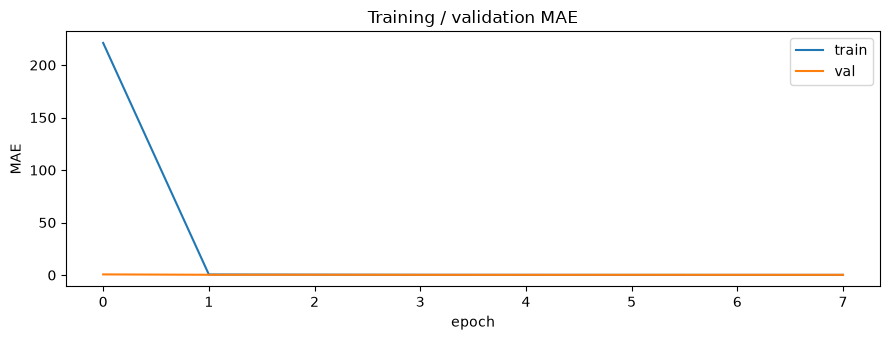

In [5]:
history = km.fit(train_ds, validation_data=val_ds, epochs=8, verbose=1)

plt.figure(figsize=(9, 3.5))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.legend()
plt.title("Training / validation MAE")
plt.tight_layout()
plt.show()

## 5. Evaluate & plot a forecast

In [6]:
preds = km.predict(val_ds, verbose=0)[..., 0]  # (n_series, PREDICTION_LENGTH)
actual = val_batch.y[..., 0]
err = actual - preds
print("MAE:", float(np.abs(err).mean()))
print("MSE:", float(np.mean(err**2)))

I0000 00:00:1787630188.029235 2074013 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17070__.1


MAE: 0.23797914385795593
MSE: 0.2298879325389862


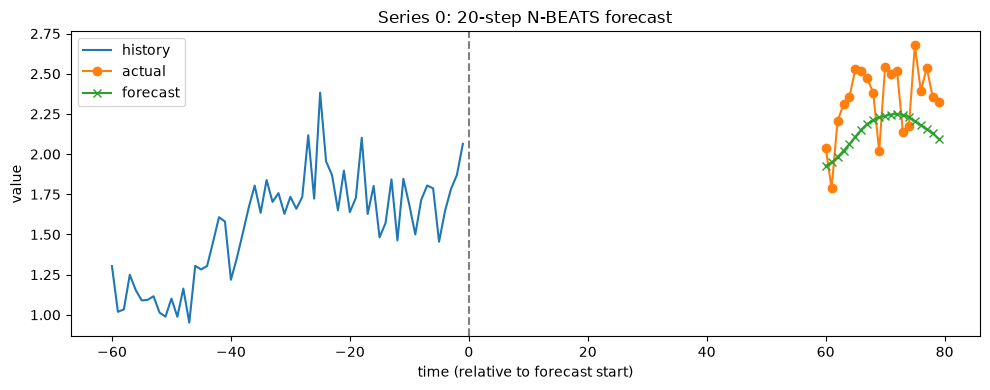

In [7]:
s = 0  # pick a series
window = val_batch.x[s, :, 0]  # history (encoder window)
fut = np.arange(ENCODER_LENGTH, ENCODER_LENGTH + PREDICTION_LENGTH)

plt.figure(figsize=(10, 4))
plt.plot(np.arange(-ENCODER_LENGTH, 0), window, label="history")
plt.plot(fut, actual[s], label="actual", marker="o")
plt.plot(fut, preds[s], label="forecast", marker="x")
plt.axvline(0, color="gray", ls="--")
plt.xlabel("time (relative to forecast start)")
plt.ylabel("value")
plt.legend()
plt.title(f"Series {s}: {PREDICTION_LENGTH}-step N-BEATS forecast")
plt.tight_layout()
plt.show()

## 6. Save, reload, and run inference

In [8]:
model.save_pretrained("./nbeats_model")
restored_model = AutoModel.from_pretrained("./nbeats_model")
restored_preds = restored_model.predict(val_batch.x, batch_size=BATCH_SIZE, verbose=0)
print("Restored prediction shape:", restored_preds.shape)

I0000 00:00:1787630189.459448 2074013 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18741__.1


Restored prediction shape: (100, 20, 1)
